# Install libraries

In [ ]:
!pip install kagglehub

import kagglehub
import os
import time
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# For reproducibility
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Download Dataset

### Dataset Source

The PlantVillage plant disease dataset was downloaded from Kaggle using KaggleHub.

Source:
https://www.kaggle.com/datasets/mohitsingh1804/plantvillage

The dataset contains labeled RGB leaf images across multiple crops and disease classes
and is widely used as a benchmark for plant disease classification research.

In [ ]:
# Download the latest version of the PlantVillage Dataset
dataset_path = kagglehub.dataset_download("mohitsingh1804/plantvillage")
dataset_path = Path(dataset_path)
print("Path to dataset files:", dataset_path)

Using Colab cache for faster access to the 'plantvillage' dataset.
Path to dataset files: /kaggle/input/plantvillage


# Locate the actual image directory

In [ ]:
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

# Find a directory that contains many subdirs, each with images
def find_image_root(base: Path):
    candidates = []
    for p in base.rglob("*"):
        if p.is_dir():
            subdirs = [d for d in p.iterdir() if d.is_dir()]
            if len(subdirs) >= 10:  # PlantVillage has many classes
                # check if at least some subdirs contain images
                img_count = 0
                for sd in subdirs[:5]:
                    img_count += sum(1 for f in sd.rglob("*") if f.suffix.lower() in IMG_EXTS)
                if img_count > 50:
                    candidates.append(p)
    # Choose the deepest (most specific) candidate
    candidates = sorted(candidates, key=lambda x: len(str(x)))
    return candidates[-1] if candidates else None

image_root = find_image_root(dataset_path)
print("Image root:", image_root)

# Show class folders count
classes = sorted([
    d.name for d in image_root.iterdir()
    if d.is_dir()
    ])[:10] # Keep only the first 10 classes
NUM_CLASSES = len(classes)

subset_counts = []
for cls in classes:
    cls_dir = image_root / cls
    n = sum(1 for p in cls_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS)
    subset_counts.append((cls, n))

df_subset = pd.DataFrame(subset_counts, columns=["Class", "Images"]).sort_values("Class")
display(df_subset)
print("Total images in 10-class subset:", df_subset["Images"].sum())

Image root: /kaggle/input/plantvillage/PlantVillage/train


,Class,Images
0,Apple___Apple_scab,504
1,Apple___Black_rot,496
2,Apple___Cedar_apple_rust,220
3,Apple___healthy,1316
4,Blueberry___healthy,1202
5,Cherry_(including_sour)___Powdery_mildew,842
6,Cherry_(including_sour)___healthy,684
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,410
8,Corn_(maize)___Common_rust_,953
9,Corn_(maize)___Northern_Leaf_Blight,788


Total images in 10-class subset: 7415


## Class Subset Selection

To reduce computational complexity and allow rapid experimentation,
the experiments were conducted on a subset of 10 plant disease classes.
The selected classes were chosen in alphabetical order to ensure
reproducibility and avoid selection bias.


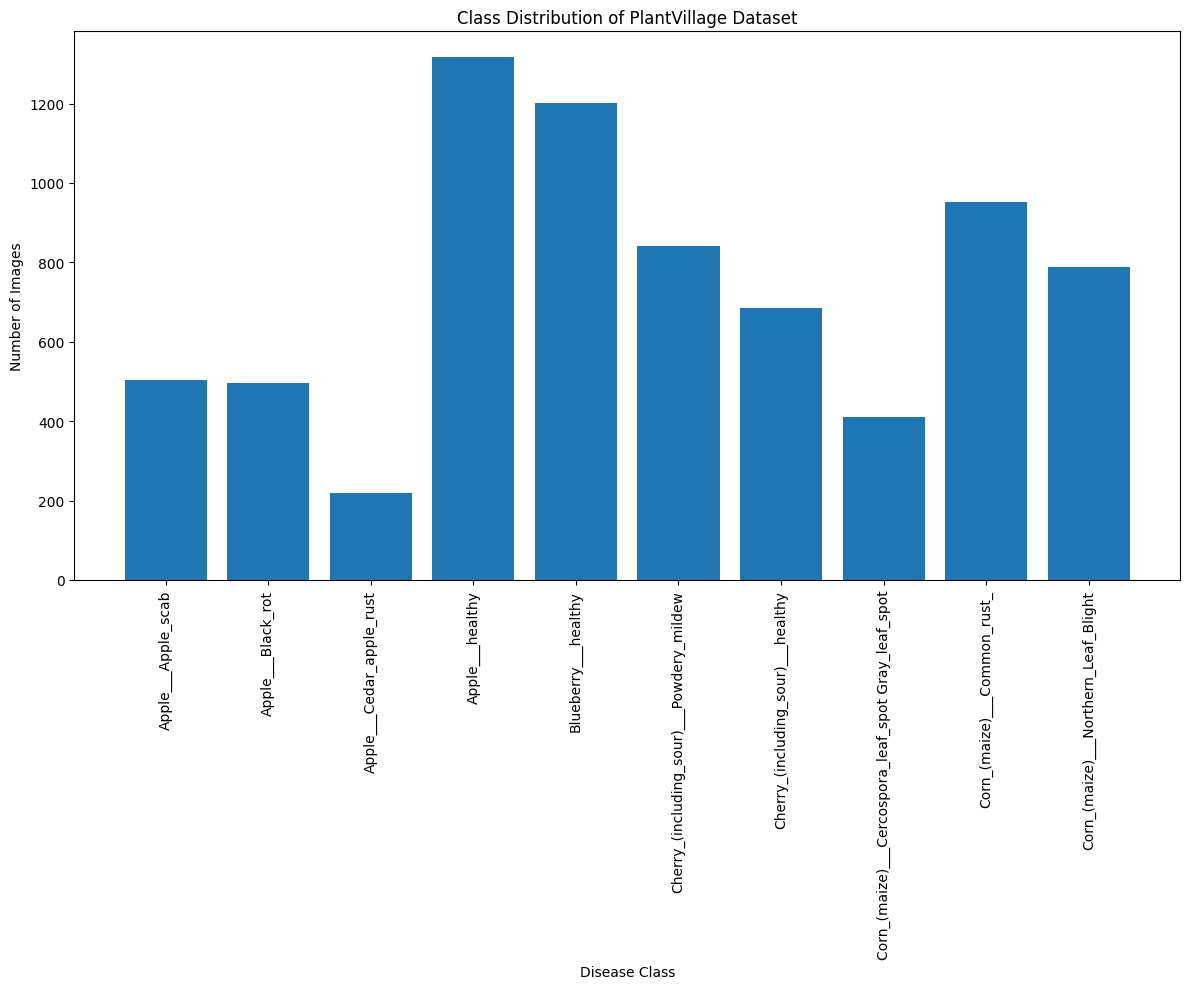

In [ ]:
import matplotlib.pyplot as plt

def count_images_in_class(cls_dir: Path):
    return sum(1 for p in cls_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS)

counts = {cls: count_images_in_class(image_root/cls) for cls in classes}

plt.figure(figsize=(12, 10))
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution of PlantVillage Dataset")
plt.ylabel("Number of Images")
plt.xlabel("Disease Class")
#plt.grid(axis="y", linestyle="--", alpha=0.6)
#plt.invert_yaxis()  # labels read top-to-bottom
plt.tight_layout()
plt.show()

# Build Train/Val/Test split

In [ ]:
SEED = 42
TEST_SIZE = 0.15
VAL_SIZE  = 0.15

class_to_idx = {name: i for i, name in enumerate(classes)}

filepaths = []
labels = []

for cls in classes:
    cls_dir = image_root / cls
    for p in cls_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            filepaths.append(str(p))
            labels.append(class_to_idx[cls])

filepaths = np.array(filepaths)
labels = np.array(labels)

print("Total samples (10 classes):", len(filepaths))

# train+val vs test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    filepaths,
    labels,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=labels
)

# train vs val (val size is relative to remaining set)
val_relative = VAL_SIZE / (1.0 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=val_relative,
    random_state=SEED,
    stratify=y_trainval
)

def split_summary(X, y, split_name):
    df = pd.DataFrame({"path": X, "label": y})
    df["class"] = df["label"].map({i: c for i, c in enumerate(classes)})
    summary = df["class"].value_counts().sort_index()
    print(f"\n{split_name} size:", len(df))
    display(summary.to_frame("count"))

split_summary(X_train, y_train, "TRAIN")
split_summary(X_val, y_val, "VAL")
split_summary(X_test, y_test, "TEST")

Total samples (10 classes): 7415

TRAIN size: 5189


,count
class,
Apple___Apple_scab,352
Apple___Black_rot,347
Apple___Cedar_apple_rust,154
Apple___healthy,921
Blueberry___healthy,841
Cherry_(including_sour)___Powdery_mildew,590
Cherry_(including_sour)___healthy,478
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,287
Corn_(maize)___Common_rust_,667



VAL size: 1113


,count
class,
Apple___Apple_scab,76
Apple___Black_rot,75
Apple___Cedar_apple_rust,33
Apple___healthy,197
Blueberry___healthy,181
Cherry_(including_sour)___Powdery_mildew,126
Cherry_(including_sour)___healthy,103
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,61
Corn_(maize)___Common_rust_,143



TEST size: 1113


,count
class,
Apple___Apple_scab,76
Apple___Black_rot,74
Apple___Cedar_apple_rust,33
Apple___healthy,198
Blueberry___healthy,180
Cherry_(including_sour)___Powdery_mildew,126
Cherry_(including_sour)___healthy,103
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,62
Corn_(maize)___Common_rust_,143


In [ ]:
# Add caching/prefetch for speed
IMG_SIZE = (224, 224)   # good common choice for MobileNetV2 + ResNet50
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
# Runtime environment info
import platform, sys

print("─" * 60)
print("─" * 15, "Environment Info", "─" * 15)
print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
print("Platform:", platform.platform())
print("BATCH_SIZE:", BATCH_SIZE)
print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))

gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)
if gpus:
    try:
        details = tf.config.experimental.get_device_details(gpus[0])
        print("GPU details:", details)
    except Exception as e:
        print("Could not fetch GPU details:", e)

────────────────────────────────────────────────────────────
─────────────── Environment Info ───────────────
Python: 3.12.12
TensorFlow: 2.19.0
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
BATCH_SIZE: 32
Num GPUs Available: 1
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU details: {'compute_capability': (8, 0), 'device_name': 'NVIDIA A100-SXM4-80GB'}


In [ ]:
# Sanity Check
unique_labels, counts_per_label = np.unique(labels, return_counts=True)

print("Label distribution:")
for lbl, cnt in zip(unique_labels, counts_per_label):
    print(f"Class {lbl} ({classes[lbl]}): {cnt} images")

Label distribution:
Class 0 (Apple___Apple_scab): 504 images
Class 1 (Apple___Black_rot): 496 images
Class 2 (Apple___Cedar_apple_rust): 220 images
Class 3 (Apple___healthy): 1316 images
Class 4 (Blueberry___healthy): 1202 images
Class 5 (Cherry_(including_sour)___Powdery_mildew): 842 images
Class 6 (Cherry_(including_sour)___healthy): 684 images
Class 7 (Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot): 410 images
Class 8 (Corn_(maize)___Common_rust_): 953 images
Class 9 (Corn_(maize)___Northern_Leaf_Blight): 788 images


In [ ]:
def decode_image(path):
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    return img

def load_preprocess(path, label):
    img = decode_image(path)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)  # keep 0..255 float
    return img, label

def make_ds(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(2000, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.cache()
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_ds(X_train, y_train, training=True)
val_ds   = make_ds(X_val, y_val, training=False)
test_ds  = make_ds(X_test, y_test, training=False)

# Visualize raw samples from the dataset (as loaded)

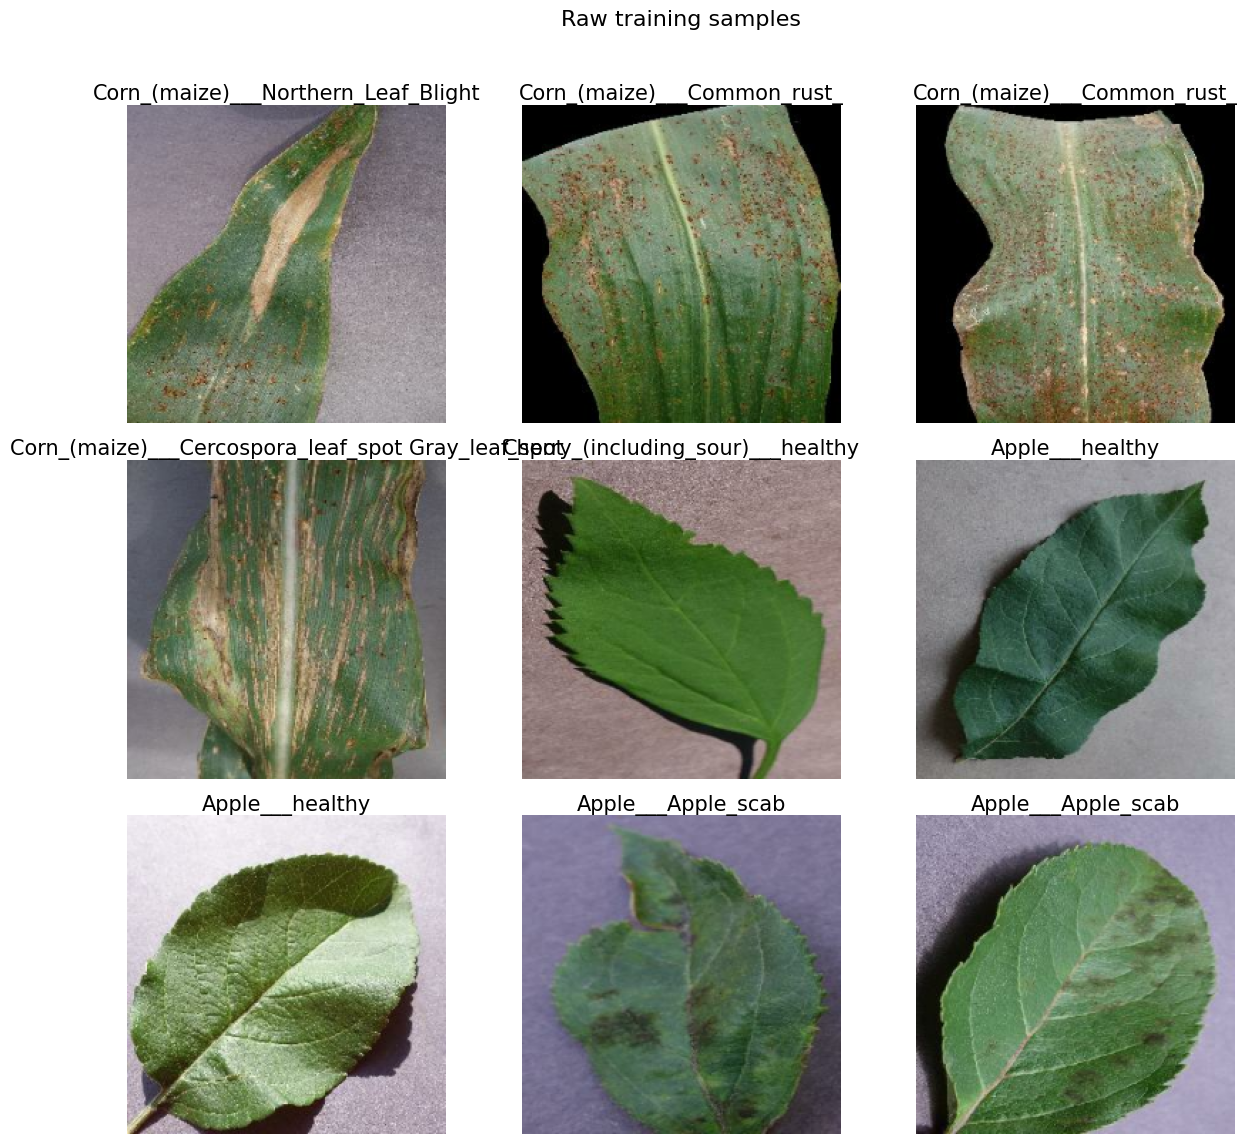

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

def show_batch(ds, classes, n=9, title="Raw samples"):
    images, labels = next(iter(ds))
    n = min(n, images.shape[0])
    # Use numpy to calculate grid size to avoid strict typing issues with tf.math.sqrt
    grid = int(np.ceil(np.sqrt(n)))

    plt.figure(figsize=(12, 12))
    plt.suptitle(title, fontsize=16, y=0.95)

    for i in range(n):
        ax = plt.subplot(grid, grid, i + 1)
        plt.imshow(tf.cast(images[i], tf.uint8))
        plt.title(classes[int(labels[i])], fontsize=15, pad=4)
        plt.axis("off")
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

show_batch(train_ds, classes, n=9, title="Raw training samples")

# Define augmentation + normalization layers

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
], name="augmentation")

# Rescale to [0,1] for baseline CNN; for pretrained models we’ll use their preprocess_input
rescale = tf.keras.layers.Rescaling(1./255)

# Model 1: Custom CNN baseline

In [ ]:
def build_custom_cnn(num_classes):
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = rescale(x)

    x = tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPool2D()(x)

    x = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPool2D()(x)

    x = tf.keras.layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPool2D()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs, name="custom_cnn")

cnn_model = build_custom_cnn(NUM_CLASSES)
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
cnn_model.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,538 (369.29 KB)

 Trainable params: 94,538 (369.29 KB)

 Non-trainable params: 0 (0.00 B)

### Transfer Learning Strategy

For MobileNetV2 and ResNet50, the pretrained convolutional backbones are frozen.
This design choice ensures:

• Fair comparison of inference speed and model size  
• Reduced risk of overfitting on a curated dataset  
• Faster training and lower computational cost  

Fine-tuning deeper layers was intentionally avoided to prioritise scalability
and deployment feasibility on resource-constrained agricultural devices.

# Model 2: MobileNetV2 (transfer learning)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

def build_mobilenetv2(num_classes):
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = mobilenet_preprocess(x)

    base = MobileNetV2(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
    base.trainable = False

    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name="mobilenetv2_tl")
    return model

mb_model = build_mobilenetv2(NUM_CLASSES)
mb_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
mb_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_tl"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Model 3: ResNet50 (transfer learning)

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess

def build_resnet50(num_classes):
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = resnet_preprocess(x)

    base = ResNet50(include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
    base.trainable = False

    x = base(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name="resnet50_tl")
    return model

rn_model = build_resnet50(NUM_CLASSES)
rn_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
rn_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "resnet50_tl"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_layer_4[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ augmentation[2][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ augmentation[2][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ augmentation[2][… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10)        │     20,490 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,608,202 (90.06 MB)

 Trainable params: 20,490 (80.04 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

# Training loop (consistent for all 3)

In [ ]:
EPOCHS = 25
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)
]

In [ ]:
# Custom CNN
hist_cnn = cnn_model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)

Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.2796 - loss: 1.9996 - val_accuracy: 0.5553 - val_loss: 1.3502
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.5401 - loss: 1.3249 - val_accuracy: 0.5930 - val_loss: 1.1863
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6244 - loss: 1.1127 - val_accuracy: 0.6963 - val_loss: 0.9295
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6879 - loss: 0.9018 - val_accuracy: 0.7655 - val_loss: 0.7336
Epoch 5/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7291 - loss: 0.7649 - val_accuracy: 0.7745 - val_loss: 0.6729
Epoch 6/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7651 - loss: 0.6798 - val_accuracy: 0.7637 - val_loss: 0.6914
Epoch 7/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.7824 - loss: 0.6150 - val_accuracy: 0.7745 - val_loss: 0.6297
Epoch 8/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8014 - loss: 0.5689 - val_acc

In [ ]:
# MobileNetV2
hist_mb  = mb_model.fit(train_ds,  validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)

Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.6086 - loss: 1.1917 - val_accuracy: 0.9353 - val_loss: 0.2446
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9326 - loss: 0.2338 - val_accuracy: 0.9551 - val_loss: 0.1621
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9520 - loss: 0.1633 - val_accuracy: 0.9551 - val_loss: 0.1440
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9559 - loss: 0.1354 - val_accuracy: 0.9605 - val_loss: 0.1203
Epoch 5/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9678 - loss: 0.1025 - val_accuracy: 0.9641 - val_loss: 0.1117
Epoch 6/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9677 - loss: 0.1017 - val_accuracy: 0.9668 - val_loss: 0.0987
Epoch 7/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9631 - loss: 0.1044 - val_accuracy: 0.9686 - val_loss: 0.0931
Epoch 8/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.9701 - loss: 0.0856 - val_acc

In [ ]:
# ResNet50
hist_rn  = rn_model.fit(train_ds,  validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)

Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.6711 - loss: 1.0263 - val_accuracy: 0.9560 - val_loss: 0.1515
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9540 - loss: 0.1661 - val_accuracy: 0.9641 - val_loss: 0.1146
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9673 - loss: 0.1087 - val_accuracy: 0.9641 - val_loss: 0.1107
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9748 - loss: 0.0817 - val_accuracy: 0.9704 - val_loss: 0.0995
Epoch 5/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9766 - loss: 0.0756 - val_accuracy: 0.9695 - val_loss: 0.0944
Epoch 6/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9760 - loss: 0.0720 - val_accuracy: 0.9721 - val_loss: 0.0851
Epoch 7/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.9814 - loss: 0.0534 - val_accuracy: 0.9712 - val_loss: 0.0877
Epoch 8/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9850 - loss: 0.0497 - val_acc

# Training History Plots

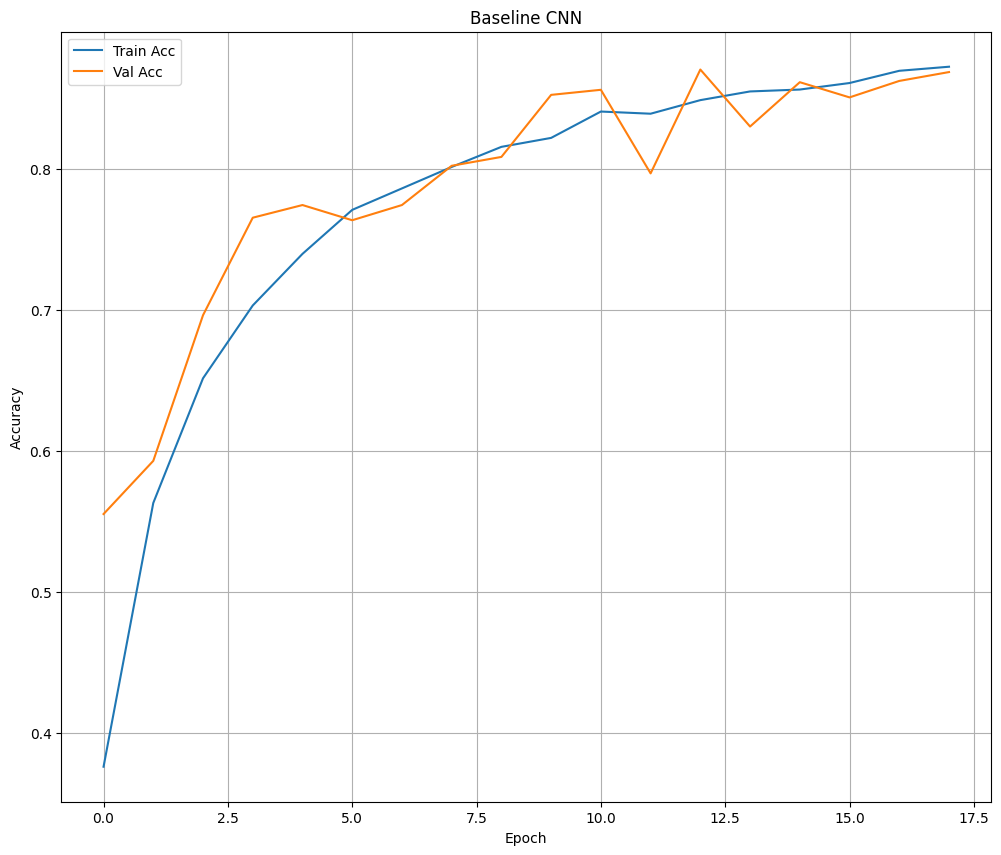

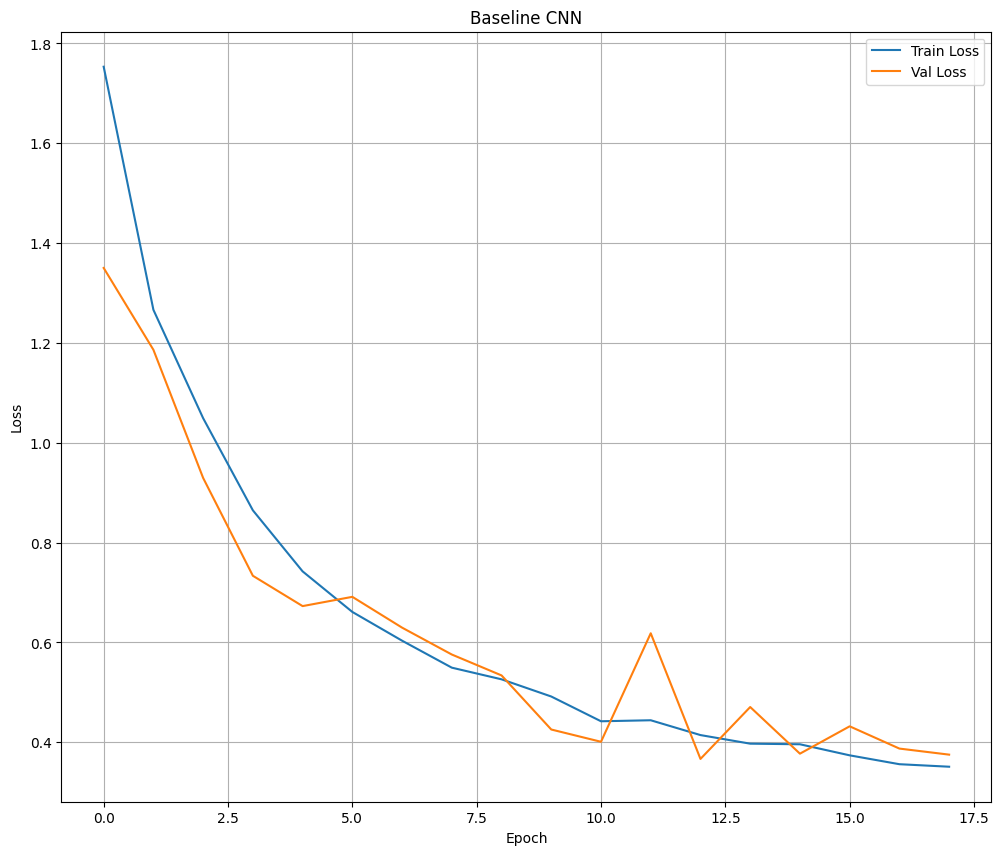

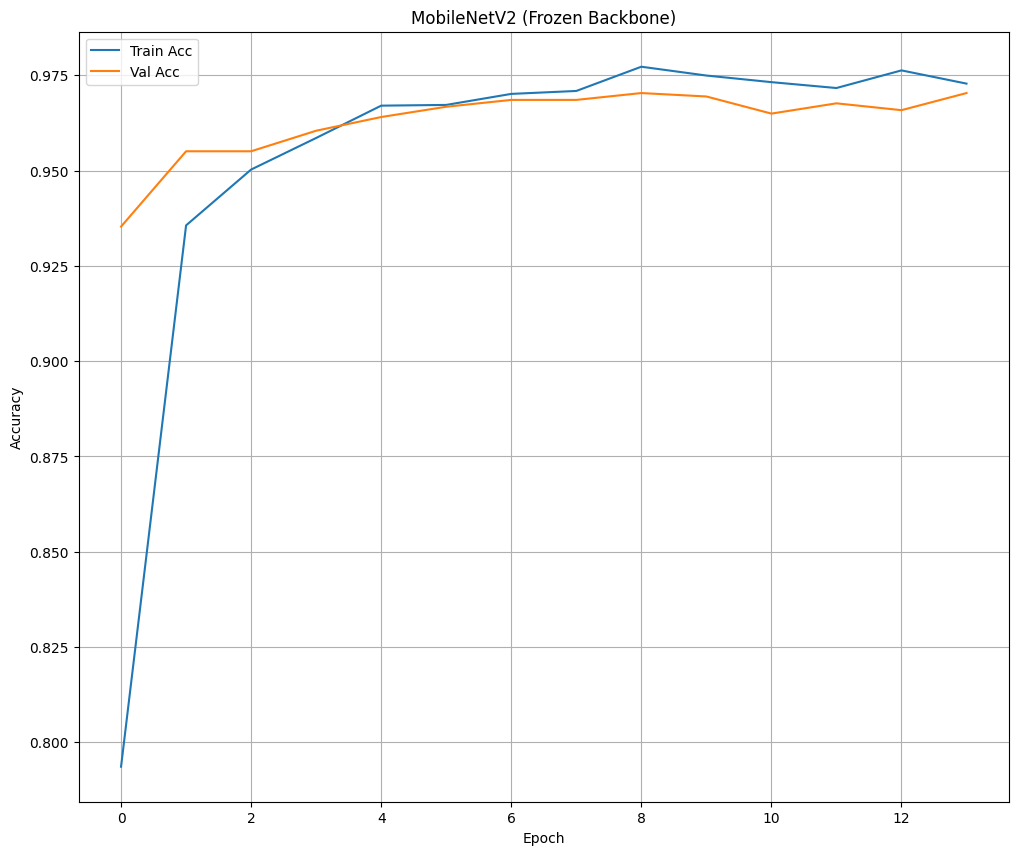

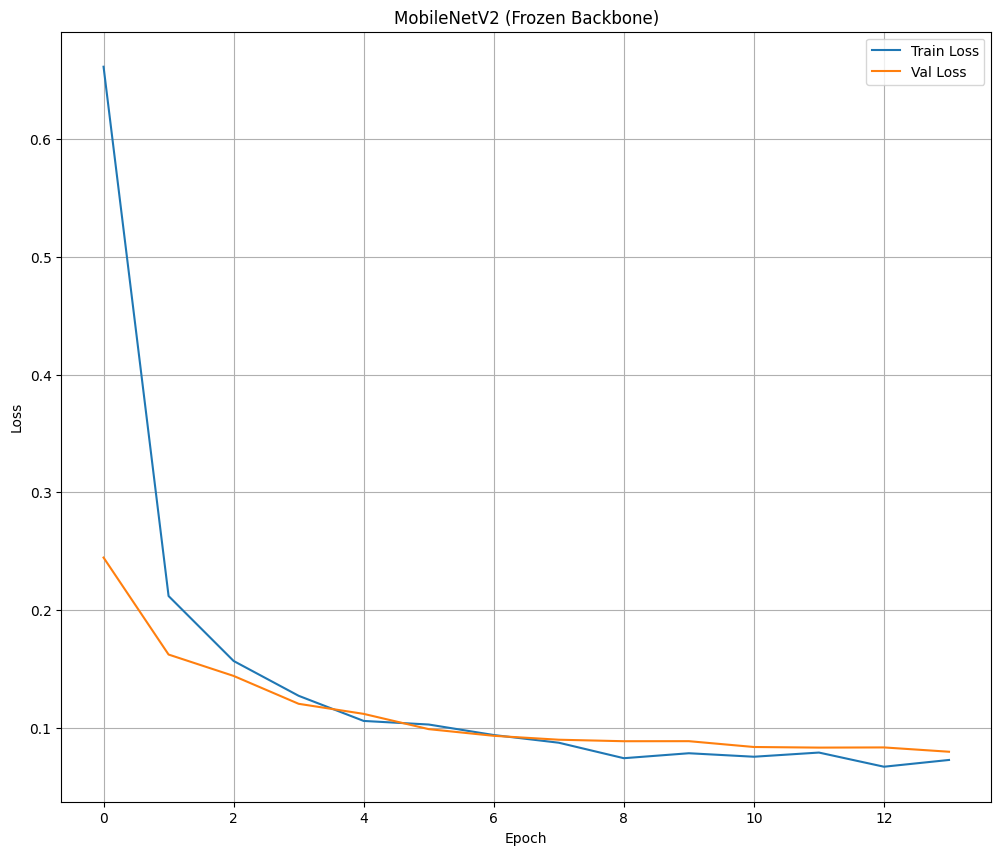

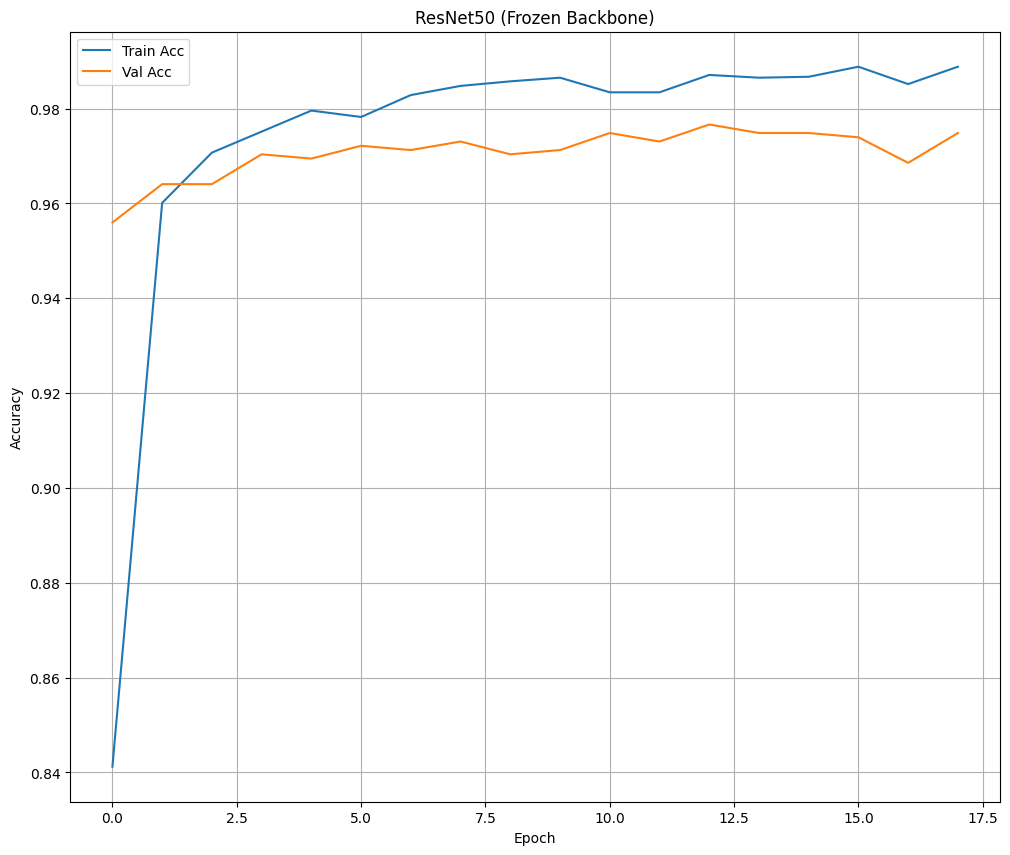

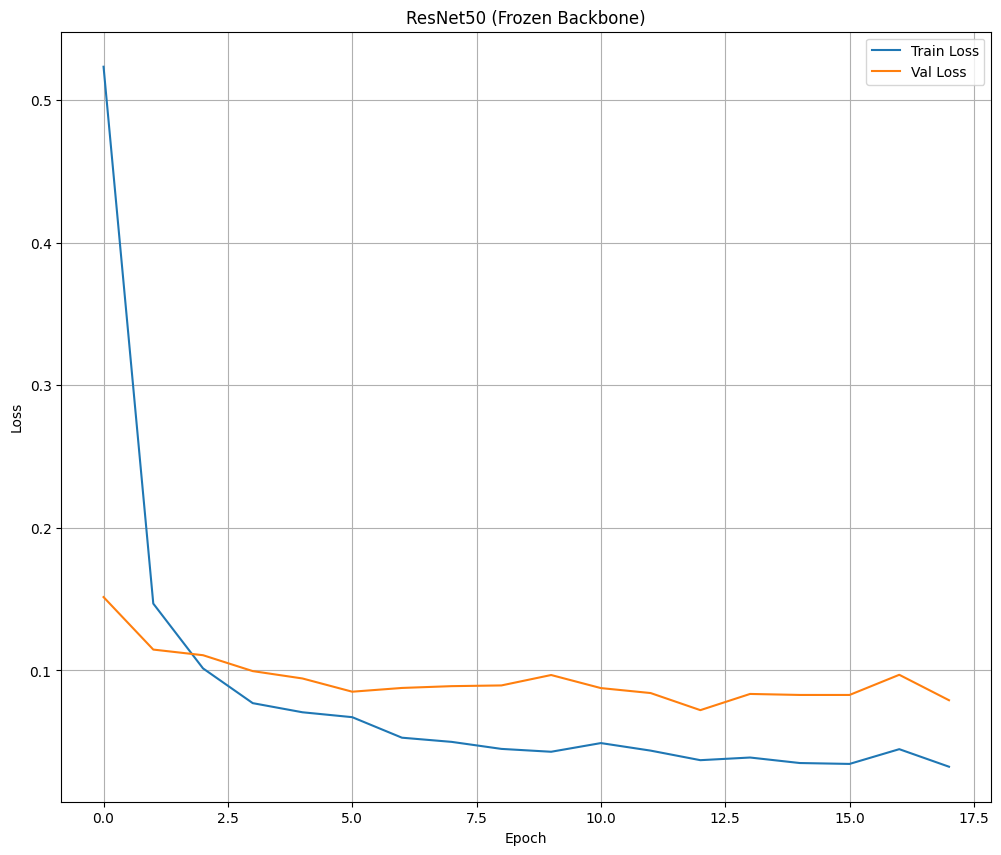

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12,10))
    plt.plot(history.history["accuracy"], label="Train Acc")
    plt.plot(history.history["val_accuracy"], label="Val Acc")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12,10))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(hist_cnn, "Baseline CNN")
plot_history(hist_mb, "MobileNetV2 (Frozen Backbone)")
plot_history(hist_rn, "ResNet50 (Frozen Backbone)")

# Evaluation metrics + confusion matrix


Custom CNN (Test)
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.8444    0.5000    0.6281        76
                                 Apple___Black_rot     0.8046    0.9459    0.8696        74
                          Apple___Cedar_apple_rust     0.8000    0.1212    0.2105        33
                                   Apple___healthy     0.9149    0.8687    0.8912       198
                               Blueberry___healthy     0.8429    0.9833    0.9077       180
          Cherry_(including_sour)___Powdery_mildew     0.7532    0.9206    0.8286       126
                 Cherry_(including_sour)___healthy     0.9439    0.9806    0.9619       103
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8571    0.5806    0.6923        62
                       Corn_(maize)___Common_rust_     0.9931    1.0000    0.9965       143
               Corn_(maize)___Northern_Leaf_Blight     0.824

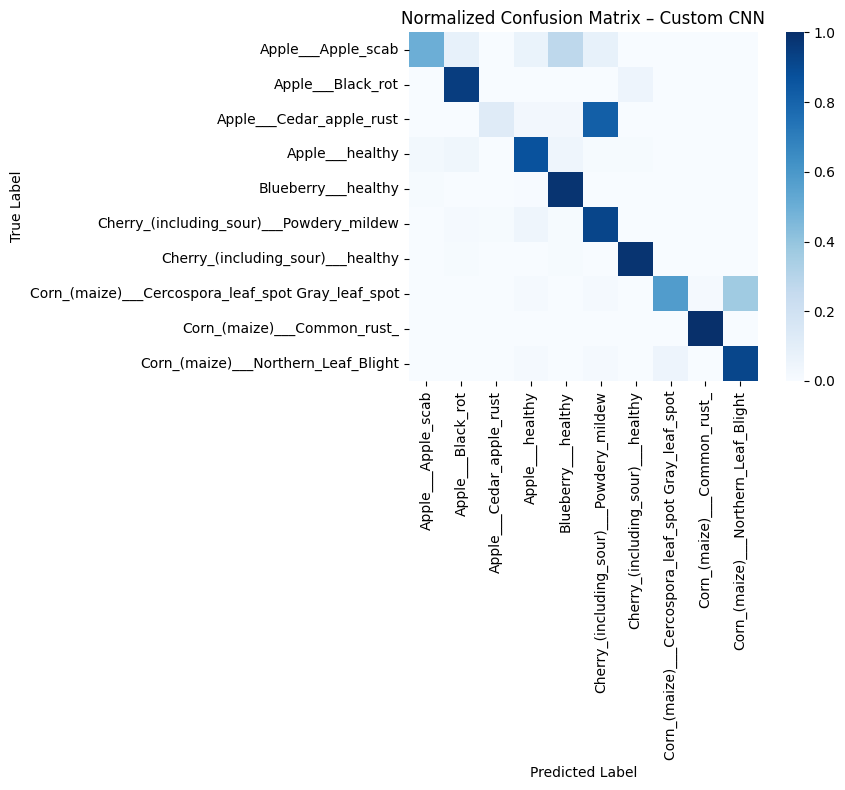

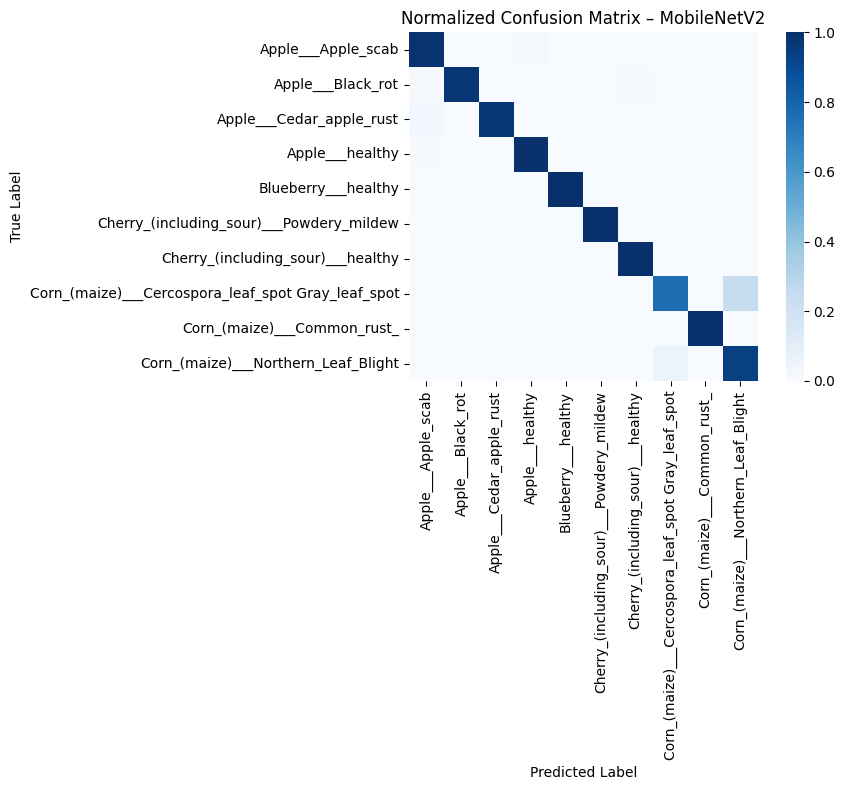

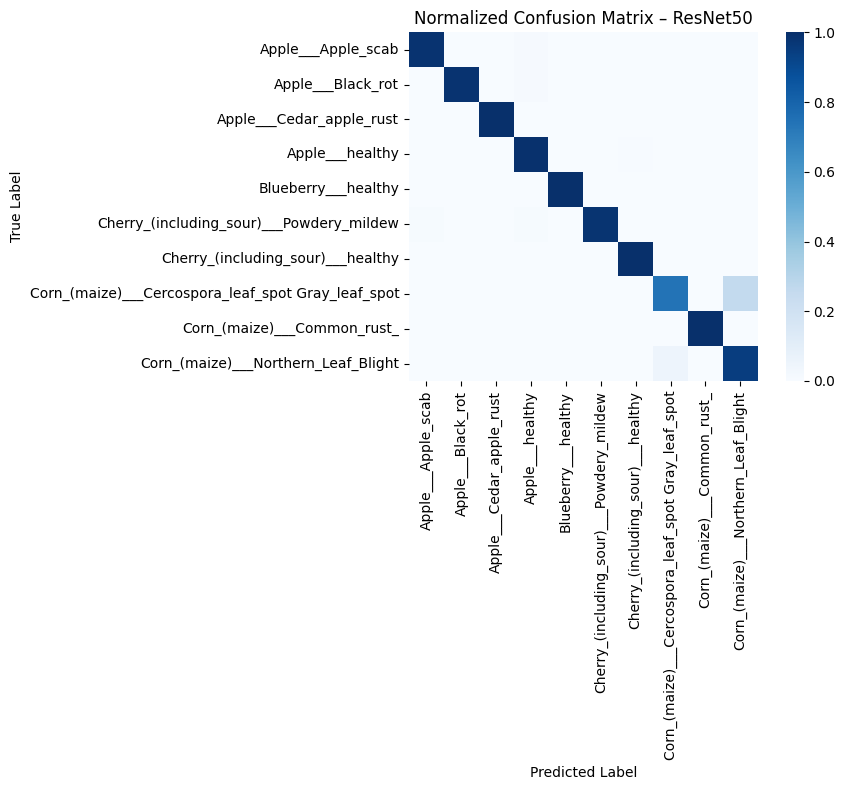

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def predict_on_ds(model, ds):
    y_true = []
    y_pred = []
    for x, y in ds:
        probs = model.predict(x, verbose=0)
        y_true.extend(y.numpy())
        y_pred.extend(np.argmax(probs, axis=1))
    return np.array(y_true), np.array(y_pred)

# Classification Report
def evaluate_model(model, ds, model_name):
    y_true, y_pred = predict_on_ds(model, ds)
    print("\n" + "="*60)
    print(model_name)
    # Added zero_division=0 to suppress the warning for classes with no predicted samples
    print(classification_report(y_true, y_pred, target_names=classes, digits=4, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    return cm

cm_cnn = evaluate_model(cnn_model, test_ds, "Custom CNN (Test)")
cm_mb  = evaluate_model(mb_model,  test_ds, "MobileNetV2 (Test)")
cm_rn  = evaluate_model(rn_model,  test_ds, "ResNet50 (Test)")

# Visualize Confusion Matrices
def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(10,8))
    sns.heatmap(
        cm,
        cmap="Blues",
        square=True,
        xticklabels=classes,
        yticklabels=classes
    )
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def normalize_cm(cm):
    cm = cm.astype("float")
    return cm / (cm.sum(axis=1, keepdims=True) + 1e-12)

plot_confusion_matrix(normalize_cm(cm_cnn), "Normalized Confusion Matrix – Custom CNN")
plot_confusion_matrix(normalize_cm(cm_mb),  "Normalized Confusion Matrix – MobileNetV2")
plot_confusion_matrix(normalize_cm(cm_rn),  "Normalized Confusion Matrix – ResNet50")

# Model size + parameter count + latency

In [ ]:
# Parameter count + saved model size

import os, tempfile

def get_model_size_mb(model):
    tmpdir = tempfile.mkdtemp()
    # Keras requires a .keras or .h5 extension for the saving format
    path = os.path.join(tmpdir, model.name + ".keras")
    model.save(path, include_optimizer=False)

    # Check if it's a single file or a directory (SavedModel format)
    if os.path.isfile(path):
        total = os.path.getsize(path)
    else:
        total = 0
        for root, _, files in os.walk(path):
            for f in files:
                total += os.path.getsize(os.path.join(root, f))
    return total / (1024**2)

for m in [cnn_model, mb_model, rn_model]:
    print(m.name, "| params:", f"{m.count_params():,}", "| size (MB):", f"{get_model_size_mb(m):.2f}")

custom_cnn | params: 94,538 | size (MB): 1.14
mobilenetv2_tl | params: 2,270,794 | size (MB): 9.33
resnet50_tl | params: 23,608,202 | size (MB): 90.86


In [ ]:
# Inference latency (ms/image)

def measure_latency(model, ds, warmup_batches=3, measure_batches=10, repeats=5):
    # Collect a fixed set of batches once (stable measurement)
    batches = list(ds.take(warmup_batches + measure_batches))

    # Warmup (one-time)
    for x, _ in batches[:warmup_batches]:
        _ = model(x, training=False)

    timings = []
    for _ in range(repeats):
        start = time.time()
        n_images = 0
        for x, _ in batches[warmup_batches:]:
            _ = model(x, training=False)
            n_images += x.shape[0]
        end = time.time()
        ms_per_img = (end - start) * 1000.0 / n_images
        timings.append(ms_per_img)

    return float(np.mean(timings)), float(np.std(timings))

print("Latency measured on TEST dataset batches (ms/image):")
for m in [cnn_model, mb_model, rn_model]:
    mean_ms, std_ms = measure_latency(m, test_ds)
    print(f"{m.name}: {mean_ms:.4f} ± {std_ms:.4f}")

Latency measured on TEST dataset batches (ms/image):
custom_cnn: 0.3471 ± 0.0600
mobilenetv2_tl: 4.4060 ± 0.0632
resnet50_tl: 6.8834 ± 0.0682


## Model Comparison (Performance vs Scalability)

This table summarizes the evaluated architectures for plant disease classification, combining **predictive performance** (macro-F1) with **deployment-relevant scalability metrics** (parameter count and inference latency).


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def compute_metrics_from_ds(model, ds):
    y_true, y_pred = predict_on_ds(model, ds)
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

def build_comparison_row(model, ds, model_label):
    metrics = compute_metrics_from_ds(model, ds)
    return {
        "Model": model_label,
        "Input Size": f"{IMG_SIZE[0]}×{IMG_SIZE[1]}",
        "Accuracy": metrics["Accuracy"],
        "Macro Precision": metrics["Macro Precision"],
        "Macro Recall": metrics["Macro Recall"],
        "Macro F1": metrics["Macro F1"],
        "Params": model.count_params(),
        "Saved Size (MB)": get_model_size_mb(model),
        "Latency (ms/image)": measure_latency(model, ds),
    }

comparison_rows = [
    build_comparison_row(cnn_model, test_ds, "Custom CNN"),
    build_comparison_row(mb_model,  test_ds, "MobileNetV2 (TL, frozen)"),
    build_comparison_row(rn_model,  test_ds, "ResNet50 (TL, frozen)"),
]

df_comp = pd.DataFrame(comparison_rows)

# clean formatting for display
df_show = df_comp.copy()
for col in ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]:
    df_show[col] = df_show[col].map(lambda x: f"{x:.4f}")
df_show["Params"] = df_show["Params"].map(lambda x: f"{x:,}")
df_show["Saved Size (MB)"] = df_show["Saved Size (MB)"].map(lambda x: f"{x:.2f}")
# Unpack the (mean, std) tuple returned by measure_latency
df_show["Latency (ms/image)"] = df_show["Latency (ms/image)"].map(lambda x: f"{x[0]:.4f} ± {x[1]:.4f}")

df_show

,Model,Input Size,Accuracy,Macro Precision,Macro Recall,Macro F1,Params,Saved Size (MB),Latency (ms/image)
0,Custom CNN,224×224,0.8670,0.8579,0.7816,0.7854,"94,538",1.14,0.3445 ± 0.0585
1,"MobileNetV2 (TL, frozen)",224×224,0.9757,0.9698,0.9623,0.9655,"2,270,794",9.33,4.3915 ± 0.0558
2,"ResNet50 (TL, frozen)",224×224,0.9757,0.9722,0.9643,0.9675,"23,608,202",90.86,6.8473 ± 0.0478


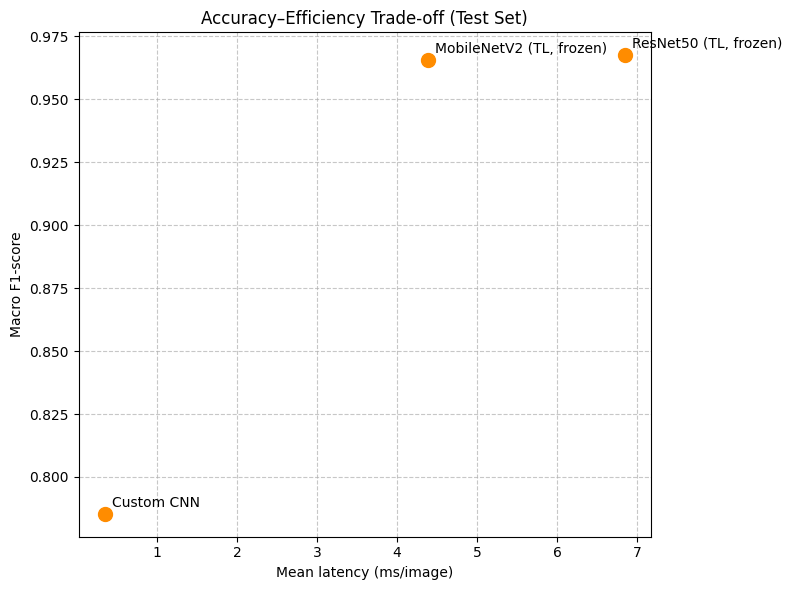

In [ ]:
import matplotlib.pyplot as plt

models = df_results["model"].tolist()
f1s = df_results["macro_f1"].astype(float).tolist()
lats = df_results["lat_ms_img"].astype(float).tolist()

plt.figure(figsize=(8,6))
plt.scatter(lats, f1s, color='darkorange', s=100)

for m, x, y in zip(models, lats, f1s):
    plt.annotate(m, (x, y), textcoords="offset points", xytext=(5,5), fontsize=10)

plt.xlabel("Mean latency (ms/image)")
plt.ylabel("Macro F1-score")
plt.title("Accuracy–Efficiency Trade-off (Test Set)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Sample Predictions from MobileNetV2

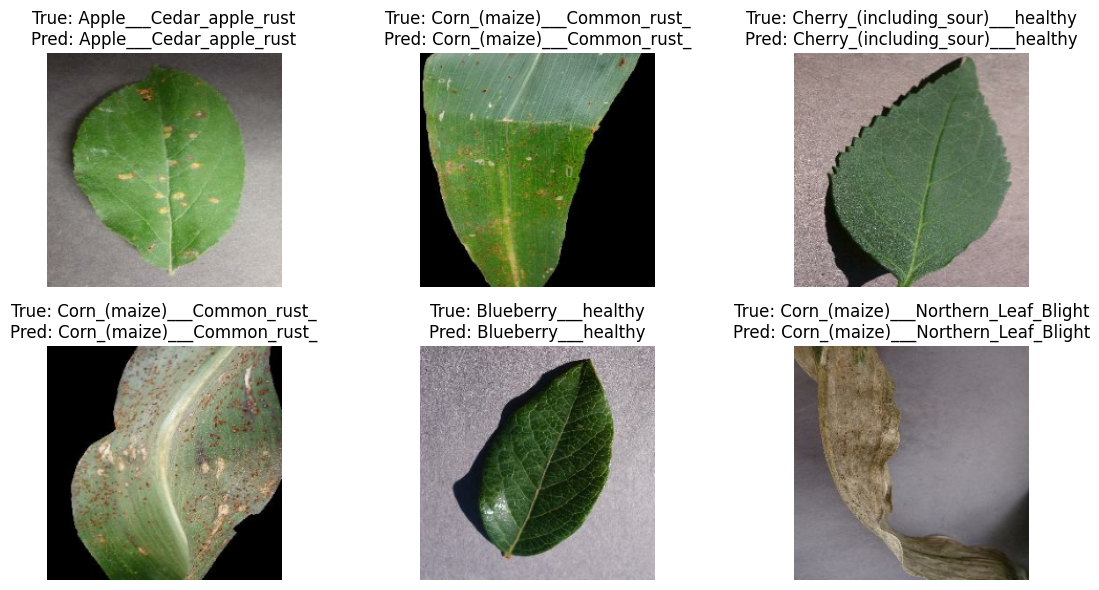

In [ ]:
def show_predictions(model, ds, classes, n=6):
    images, labels = next(iter(ds))
    preds = model.predict(images, verbose=0)
    preds = tf.argmax(preds, axis=1)

    plt.figure(figsize=(12,6))
    for i in range(n):
        ax = plt.subplot(2, 3, i+1)
        img = images[i].numpy()
        img = np.clip(img, 0, 255).astype(np.uint8) if img.max() > 1.5 else (np.clip(img, 0, 1) * 255).astype(np.uint8)
        plt.imshow(img)
        plt.title(f"True: {classes[labels[i]]}\nPred: {classes[preds[i]]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_predictions(mb_model, test_ds, classes)

### Detailed Comparison: MobileNetV2 vs. ResNet50

Based on the experimental results, here is a breakdown of the trade-offs between the two architectures for plant disease classification:

#### 1. Model Complexity & Size
*   **MobileNetV2**: Uses **depthwise separable convolutions**, which significantly reduce the number of parameters and operations (MACs). It has **2,270,794 parameters** and a footprint of **9.33 MB**.
*   **ResNet50**: A much deeper architecture (50 layers) using standard convolutions and residual skip connections. It has **23,608,202 parameters** and a footprint of **90.86 MB**.
*   **Trade-off**: MobileNetV2 is **~10x smaller**, making it far more suitable for mobile apps or low-power agricultural sensors where storage and RAM are limited.

#### 2. Inference Speed (Latency)
*   **MobileNetV2**: Average latency of **4.3915 ± 0.0558 ms/image** (at batch size 32).
*   **ResNet50**: Average latency of **6.8473 ± 0.0478 ms/image**.
*   **Trade-off**: MobileNetV2 is roughly **1.5x faster**. While the absolute difference is small per image, in high-throughput or real-time scenarios, this leads to significant cumulative time and energy savings.

#### 3. Predictive Performance
*   **Accuracy/F1**: Both models achieved an identical accuracy of **97.57%**. ResNet50 showed a slightly higher Macro F1-score (**0.9675 vs 0.9655**) in this run.
*   **Trade-off**: For the 10-class PlantVillage subset, the massive increase in capacity of ResNet50 provides negligible performance gains compared to the highly efficient MobileNetV2.

#### 4. Summary Recommendation
For most agricultural AI tasks, **MobileNetV2 is the superior choice**. It provides state-of-the-art accuracy with a fraction of the hardware requirements. ResNet50 should only be considered if the problem is significantly more complex (e.g., hundreds of classes) and compute resources are not a constraint.